In [2]:
from ultralytics import YOLO
import cv2
import numpy as np

# Object detection

In [ ]:
# Load a pretrained YOLO26 model
model = YOLO("yolo26n.pt")

# Train on kitti dataset
results = model.train(data="kitti.yaml", epochs=100, imgsz=640)

Ultralytics 8.4.71 🚀 Python-3.12.3 torch-2.12.0+cu130 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=kitti.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

# Object Tracking

In [6]:
# Load my custom model
model = YOLO("runs/detect/train-3/weights/best.pt")  # Load a custom-trained model

# Perform tracking with the model
results = model.track(source="video.mp4",stream=True,save=True)

for r in results:
    pass


video 1/1 (frame 1/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 1 pedestrian, 21.1ms
video 1/1 (frame 2/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 1 pedestrian, 20.5ms
video 1/1 (frame 3/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 18.9ms
video 1/1 (frame 4/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 2 pedestrians, 18.7ms
video 1/1 (frame 5/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 2 pedestrians, 16.1ms
video 1/1 (frame 6/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 2 pedestrians, 16.1ms
video 1/1 (frame 7/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 1 pedestrian, 16.1ms
video 1/1 (frame 8/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 16.1ms
video 1/1 (frame 9/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 1 truck, 16.3ms
video 1/1 (frame 10/935) /home/mrrobot/my_first_pytorch/video.mp4: 384x640 1 van, 1 pedestrian, 15.4ms
video 1/

# Farneback Optical Flow

In [4]:
cap = cv2.VideoCapture("video.mp4")

ret, frame1 = cap.read()
prvs = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)

h, w = frame1.shape[:2]
fps = cap.get(cv2.CAP_PROP_FPS)

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter('Farneback_output.mp4',fourcc,fps,(w, h))

hsv = np.zeros_like(frame1)
hsv[..., 1] = 255

while True:
    ret, frame2 = cap.read()
    if not ret:
        break

    nxt = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)

    flow = cv2.calcOpticalFlowFarneback(
        prvs, nxt,
        None,
        0.5, 3, 15, 3, 5, 1.2, 0
    )

    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    hsv[..., 0] = ang * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(
        mag, None, 0, 255, cv2.NORM_MINMAX
    )

    rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

    out.write(rgb)

    prvs = nxt

cap.release()
out.release()

print("Saved: Farneback_output.mp4")

Saved: Farneback_output.mp4


# RAFT(Recurrent All-Pairs Field Transforms) with PyTorch

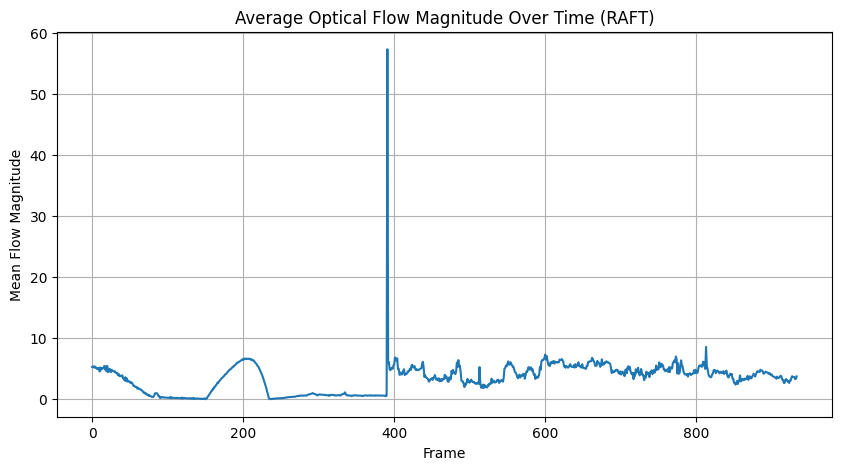

Saved video + plotted motion graph


In [2]:
import torch
import matplotlib.pyplot as plt
from torchvision.models.optical_flow import raft_large, Raft_Large_Weights
from torchvision.utils import flow_to_image

# -----------------------------
# Load RAFT
# -----------------------------
weights = Raft_Large_Weights.DEFAULT
transforms = weights.transforms()

device = "cuda" if torch.cuda.is_available() else "cpu"

model = raft_large(weights=weights, progress=True).to(device)
model.eval()

# -----------------------------
# Video
# -----------------------------
video_path = "video.mp4"
cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

out = cv2.VideoWriter("raft_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (width, height))

ret, prev_frame = cap.read()
if not ret:
    raise RuntimeError("Cannot read video")

magnitudes = []

# -----------------------------
# Process video
# -----------------------------
with torch.no_grad():

    while True:

        ret, curr_frame = cap.read()
        if not ret:
            break

        # BGR -> RGB
        img1 = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2RGB)
        img2 = cv2.cvtColor(curr_frame, cv2.COLOR_BGR2RGB)

        # to tensor
        img1 = torch.from_numpy(img1).permute(2, 0, 1).unsqueeze(0)
        img2 = torch.from_numpy(img2).permute(2, 0, 1).unsqueeze(0)

        img1, img2 = transforms(img1, img2)

        img1 = img1.to(device)
        img2 = img2.to(device)

        # RAFT inference
        flow_predictions = model(img1, img2)
        flow = flow_predictions[-1][0]   # [2, H, W]

        # -------------------------
        #  MAGNITUDE
        # -------------------------
        mag = torch.sqrt(flow[0]**2 + flow[1]**2)
        mean_mag = mag.mean().item()
        magnitudes.append(mean_mag)

        # -------------------------
        # Visualization
        # -------------------------
        flow_img = flow_to_image(flow_predictions[-1])

        flow_img = (flow_img[0].permute(1, 2, 0).cpu().numpy())
        
        # RGB -> BGR for OpenCV
        flow_img = cv2.cvtColor(flow_img, cv2.COLOR_RGB2BGR)
        
        # resize to original video size
        flow_img = cv2.resize(flow_img, (width, height))

        out.write(flow_img)

        prev_frame = curr_frame

cap.release()
out.release()

# -----------------------------
# Plot graph
# -----------------------------
plt.figure(figsize=(10,5))
plt.plot(magnitudes)
plt.title("Average Optical Flow Magnitude Over Time (RAFT)")
plt.xlabel("Frame")
plt.ylabel("Mean Flow Magnitude")
plt.grid()
plt.show()

print("Saved video + plotted motion graph")